# Chapter 11: The Homogeneous Model

This standalone notebook covers the homogeneous model from printed pages 271-326 of *Geometric Algebra for Computer Science*. I verified that the requested span maps to PDF pages 298-353 in the local file, beginning with the chapter title on printed page 271 and ending with the perspective-projection programming exercise on printed page 326. The notebook is original course prose and executable reconstruction: it follows the chapter's headings and ideas, but the explanations, examples, data, and figures here are freshly written for this workspace.

The governing move is simple and extremely productive: represent geometry in a base space by vectors and blades in a representation space with one extra coordinate. In two dimensions this means a point is stored as `[x, y, w]`; finite points have nonzero `w`, and the Euclidean location is `[x / w, y / w]`. Points with `w = 0` are not errors. They are the directions or points at infinity that make projective incidence uniform.

That extra coordinate also changes what it means to program geometry. A line through two points is no longer a special-purpose object built from slope and intercept. It is the join of two homogeneous point vectors. The intersection of two lines is their meet. Parallel lines meet too, but the meet has zero weight and therefore records their shared direction rather than a finite location. Planes, higher flats, direct blades, and dual equations fit the same habit. This notebook uses small transparent arrays to make that habit checkable in code.

The chapter's deeper warning is just as important as its construction. The homogeneous model is excellent for incidence, projective transformations, affine transformations, and ratios that survive projective change. It is not a complete Euclidean metric model. A naive inner product in the representation space can depend on the artificial coordinate, so metric quantities must be recovered from the base space or treated with care. The conformal model in later chapters will repair that limitation with two extra dimensions; here we learn exactly what one extra dimension gives us and where it stops.

## PDF Heading Audit

Before building the notebook, I extracted the requested printed page span from the local PDF and checked the section starts. The audit is saved as an artifact so the notebook records its source span without copying textbook prose. The sequence confirms that the chapter begins with homogeneous representation space, develops finite and infinite points, turns points into lines and planes as blades, generalizes to k-flats, then separates direct and dual representations. It continues through incidence, relative orientation, distance ratios and cross ratios, transformations, coordinate-free parameterized constructions, metric products, exercises, and the programming examples ending in perspective projection.

This matters because Chapter 11 is not just a list of projective-coordinate tricks. The order is pedagogical. First it defines the carrier space and the point embedding. Then it shows that outer products create flats. Only after those representations are stable does it introduce meet and join, which are the operations that let programs combine geometric objects generically. Transformations then become outermorphisms on direct blades and inverse-adjoint maps on dual blades. The later sections are a stress test: cross ratios show a projective invariant that the model handles well, while metric products show where the model does not have the full Euclidean story.

The code cell below writes the verified headings and page span to `artifacts/chapter-11/pdf-heading-verification/heading-verification.json`. The headings are included as factual navigation metadata; the explanatory material in the rest of the notebook is original.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter11_homogeneous.py").exists():
        BOOK_ROOT = candidate
        break
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib
import utils.chapter11_homogeneous as h

ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_ARTIFACTS = ARTIFACT_ROOT / "chapter-11"
CHAPTER_ARTIFACTS.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=4, suppress=True)

heading_audit = {
    "source_pdf": "Geometric Algebra for Computer Science.pdf",
    "printed_page_span": [271, 326],
    "pdf_page_span": [298, 353],
    "headings": [
        [272, "11.1 HOMOGENEOUS REPRESENTATION SPACE"],
        [274, "11.2 ALL POINTS ARE VECTORS"],
        [274, "11.2.1 FINITE POINTS"],
        [275, "11.2.2 INFINITE POINTS AND ATTITUDES"],
        [276, "11.2.3 ADDITION OF POINTS"],
        [278, "11.2.4 TERMINOLOGY: FROM PRECISE TO CONVENIENT"],
        [278, "11.3 ALL LINES ARE 2-BLADES"],
        [278, "11.3.1 FINITE LINES"],
        [282, "11.3.2 LINES AT INFINITY"],
        [282, "11.3.3 DON'T ADD LINES"],
        [283, "11.4 ALL PLANES ARE 3-BLADES"],
        [285, "11.5 k-FLATS AS (k + 1)-BLADES"],
        [285, "11.5.1 FINITE k-FLATS"],
        [285, "11.5.2 INFINITE k-FLATS"],
        [285, "11.5.3 PARAMETERS OF k-FLATS"],
        [286, "11.5.4 THE NUMBER OF PARAMETERS OF AN OFFSET FLAT"],
        [286, "11.6 DIRECT AND DUAL REPRESENTATIONS OF FLATS"],
        [286, "11.6.1 DIRECT REPRESENTATION"],
        [288, "11.6.2 DUAL REPRESENTATION"],
        [292, "11.7 INCIDENCE RELATIONSHIPS"],
        [292, "11.7.1 EXAMPLES OF INCIDENCE COMPUTATIONS"],
        [296, "11.7.2 RELATIVE ORIENTATION"],
        [298, "11.7.3 RELATIVE LENGTHS: DISTANCE RATIO AND CROSS RATIO"],
        [302, "11.8 LINEAR TRANSFORMATIONS: MOTIONS AND MORE"],
        [302, "11.8.1 LINEAR TRANSFORMATIONS ON BLADES"],
        [303, "11.8.2 TRANSLATIONS"],
        [304, "11.8.3 ROTATION AROUND THE ORIGIN"],
        [305, "11.8.4 GENERAL ROTATION"],
        [305, "11.8.5 RIGID BODY MOTION"],
        [305, "11.8.6 CONSTRUCTING ELEMENTS THROUGH MOTIONS"],
        [306, "11.8.7 RIGID BODY MOTION OUTERMORPHISMS AS MATRICES"],
        [306, "11.8.8 AFFINE TRANSFORMATIONS"],
        [308, "11.8.9 PROJECTIVE TRANSFORMATIONS"],
        [309, "11.9 COORDINATE-FREE PARAMETERIZED CONSTRUCTIONS"],
        [312, "11.10 METRIC PRODUCTS IN THE HOMOGENEOUS MODEL"],
        [312, "11.10.1 NON-EUCLIDEAN RESULTS"],
        [314, "11.10.2 NONMETRIC ORTHOGONAL PROJECTION"],
        [315, "11.11 FURTHER READING"],
        [316, "11.12 EXERCISES"],
        [316, "11.12.1 DRILLS"],
        [316, "11.12.2 STRUCTURAL EXERCISES"],
        [320, "11.13 PROGRAMMING EXAMPLES AND EXERCISES"],
        [320, "11.13.1 WORKING WITH POINTS"],
        [322, "11.13.2 INTERSECTING PRIMITIVES"],
        [324, "11.13.3 DON'T ADD LINES"],
        [325, "11.13.4 PERSPECTIVE PROJECTION"],
    ],
}
heading_path = save_json(
    heading_audit,
    "chapter-11",
    "pdf-heading-verification",
    "heading-verification.json",
    root=ARTIFACT_ROOT,
)
heading_path

WindowsPath('Geometric-Algebra-for-Computer-Science/artifacts/chapter-11/pdf-heading-verification/heading-verification.json')

## Homogeneous Representation Space

The representation space has one more dimension than the base space. In this notebook's 2-D examples, a Euclidean point `(x, y)` becomes the homogeneous vector `[x, y, 1]`. Multiplying that vector by any nonzero scalar changes its representative but not its location. This is why `[2, -1, 1]`, `[4, -2, 2]`, and `[-6, 3, -3]` all describe the same finite point. The recoverable location is the ratio between the directional coordinates and the weight.

The extra coordinate is not a hidden physical axis. It is a bookkeeping axis that lets translations become linear maps and lets offset flats be represented by blades through the origin of the representation space. In the book's notation the origin point is carried by `e0`; in the array convention here, that distinguished coordinate is the final entry. Nothing depends on whether we draw it first or last, as long as we are consistent about extraction and transformation rules.

A point with zero weight has no finite affine location. Instead of rejecting it, the homogeneous model interprets it as an attitude or point at infinity. The vector `[1, 0, 0]` is the horizontal direction, `[0, 1, 0]` is the vertical direction, and other nonzero zero-weight vectors mark other directions. This is the first reward of the model: finite locations and directions live in the same vector representation, but the weight tells us which interpretation is valid.

The figure below draws finite point representatives on the affine plane and directions as arrows from a small inset origin. The numerical table deliberately uses scaled representatives to emphasize that projective meaning lives in ratios rather than raw coordinate size.

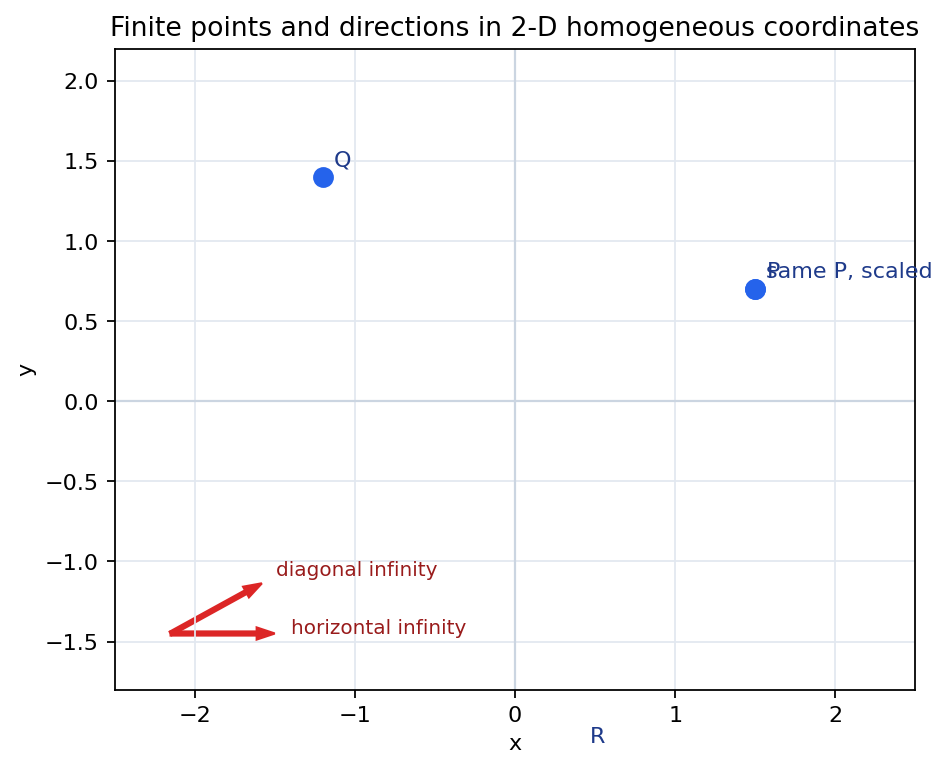

[('P', array([1.5, 0.7, 1. ]), 1.0, array([1.5, 0.7])),
 ('same P, scaled', array([4.5, 2.1, 3. ]), 3.0, array([1.5, 0.7])),
 ('Q', array([-1.2,  1.4,  1. ]), 1.0, array([-1.2,  1.4])),
 ('R', array([ 0.2, -1.1,  0.5]), 0.5, array([ 0.4, -2.2])),
 ('horizontal infinity', array([1., 0., 0.]), 'infinite', array([1., 0.])),
 ('diagonal infinity',
  array([1.  , 0.55, 0.  ]),
  'infinite',
  array([0.8762, 0.4819]))]

In [2]:
finite_representatives = {
    "P": h.hpoint2(1.5, 0.7, 1.0),
    "same P, scaled": h.hpoint2(4.5, 2.1, 3.0),
    "Q": h.hpoint2(-1.2, 1.4, 1.0),
    "R": h.hpoint2(0.2, -1.1, 0.5),
}
infinite_representatives = {
    "horizontal infinity": h.point_at_infinity2([1.0, 0.0]),
    "diagonal infinity": h.point_at_infinity2([1.0, 0.55]),
}
rows = []
for label, point in {**finite_representatives, **infinite_representatives}.items():
    if h.is_infinite(point):
        rows.append((label, point, "infinite", h.normalize(point[:2])))
    else:
        rows.append((label, point, h.weight(point), h.affine_location(point)))

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.axhline(0, color="#cbd5e1", lw=1)
ax.axvline(0, color="#cbd5e1", lw=1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.8, 2.2)
ax.set_title("Finite points and directions in 2-D homogeneous coordinates")
ax.set_xlabel("x")
ax.set_ylabel("y")
for label, point in finite_representatives.items():
    xy = h.affine_location(point)
    ax.scatter(*xy, s=70, color="#2563eb")
    ax.text(xy[0] + 0.07, xy[1] + 0.07, label, color="#1e3a8a")
for label, point in infinite_representatives.items():
    direction = h.normalize(point[:2])
    start = np.array([-2.15, -1.45])
    ax.arrow(start[0], start[1], 0.65 * direction[0], 0.65 * direction[1],
             width=0.025, color="#dc2626", length_includes_head=True)
    ax.text(start[0] + 0.75 * direction[0], start[1] + 0.75 * direction[1], label,
            color="#991b1b", fontsize=9)
ax.grid(True, color="#e2e8f0")
rep_path = save_matplotlib(fig, "chapter-11", "representation-space", "finite-and-infinite-points.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(rep_path, width=760)
rows

## Finite Points, Infinite Points, and Addition

Adding homogeneous point representatives is meaningful only after we ask what the weights mean. If the weights are masses, then adding representatives and normalizing gives a center of mass. If the weights are arbitrary projective scales, addition is usually just addition of representatives, not addition of geometric points. This is a place where homogeneous coordinates are powerful but easy to overread.

The safest rule is to separate three ideas. First, a finite point is a vector with nonzero weight, and its location is found by dividing by that weight. Second, an infinite point is a zero-weight vector that stores a direction. Third, sums of representatives are geometric constructions only when the weights are part of the intended construction. The same vector operation can therefore be either meaningful or meaningless depending on the modeling contract.

The line examples later show why this caution matters. Two line blades can be added as arrays, but their sum is a line only in special cases, such as when they share a factor or have the same direction. The homogeneous model does not abolish geometric interpretation. It gives us a compact algebraic language, then asks us to check grade, factorization, and incidence before naming a result.

The next cell constructs weighted point averages and a pure direction. Notice that a weighted average remains finite because the total weight is nonzero. By contrast, the difference between two finite points with the same weight cancels the distinguished coordinate and becomes a direction. This is exactly the computational distinction that ordinary affine geometry usually keeps in separate point and vector types.

In [3]:
A = h.hpoint2(-1.0, 0.5, 2.0)
B = h.hpoint2(2.0, 1.25, 1.0)
center = h.weighted_average([A, B])
direction_ab = h.normalize_hpoint(B) - h.normalize_hpoint(A)

point_summary = {
    "A_location": h.affine_location(A).round(4).tolist(),
    "B_location": h.affine_location(B).round(4).tolist(),
    "weighted_average_location": h.affine_location(center).round(4).tolist(),
    "difference_weight": float(direction_ab[-1]),
    "difference_direction": direction_ab[:2].round(4).tolist(),
}
point_summary_path = save_json(point_summary, "chapter-11", "point-arithmetic", "point-summary.json", root=ARTIFACT_ROOT)
point_summary

{'A_location': [-0.5, 0.25],
 'B_location': [2.0, 1.25],
 'weighted_average_location': [0.3333, 0.5833],
 'difference_weight': 0.0,
 'difference_direction': [2.5, 1.0]}

## Flats as Blades: Lines, Planes, and k-Flats

In the homogeneous model, an offset flat in the base space becomes a homogeneous subspace through the representation-space origin. In two dimensions, a finite line is the span of two homogeneous point vectors. Algebraically that span is a 2-blade. In coordinate code, the same operation appears as a cross product because the dual of a 2-blade in three coordinates is a line equation. If `l = [a, b, c]`, then a finite point `[x, y, 1]` lies on the line exactly when `a*x + b*y + c = 0`.

The point at infinity on a line is obtained by meeting the line with the line at infinity, or more simply by using the line's direction. Parallel finite lines have the same infinite point. This is one of the cleanest demonstrations of the model: the meet of two parallel lines is not a failure case. It is a valid homogeneous point with zero weight.

In 3-D, the direct line is a 2-blade and the direct plane is a 3-blade. Practical graphics code often uses Plucker coordinates for lines and normal-offset coordinates for planes. Those are coordinate shadows of the same blade and dual-blade story. The notebook uses both, because arrays make the computations easy to audit while the prose keeps the geometric meaning visible.

The figure below shows two ordinary intersecting lines and two parallel lines. The finite meet is drawn as a point; the parallel meet is reported as an infinite point whose direction matches both lines. This is incidence as an always-returning operation, not a branchy special case.

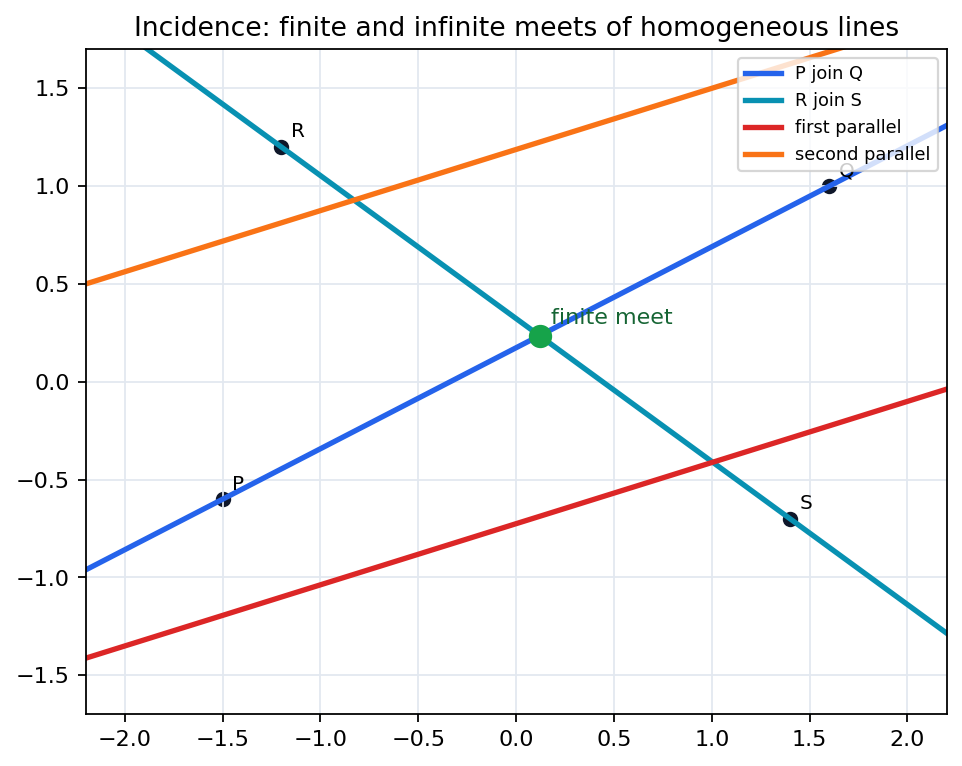

{'finite_meet': [-1.2, -2.37, -10.05],
 'finite_meet_location': [0.119403, 0.235821],
 'parallel_meet': [4.381063, 1.369082, 0.0],
 'parallel_meet_is_infinite': True,
 'parallel_direction': [0.95448, 0.298275]}

In [4]:
P = h.hpoint2(-1.5, -0.6)
Q = h.hpoint2(1.6, 1.0)
R = h.hpoint2(-1.2, 1.2)
S = h.hpoint2(1.4, -0.7)
L_pq = h.join_points(P, Q)
L_rs = h.join_points(R, S)
finite_meet = h.meet_lines(L_pq, L_rs)

T = h.hpoint2(-1.2, -1.1)
U = h.hpoint2(1.2, -0.35)
L_tu = h.join_points(T, U)
parallel = h.parallel_line_through(h.hpoint2(-1.4, 0.75), L_tu)
infinite_meet = h.meet_lines(L_tu, parallel)

fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.set_title("Incidence: finite and infinite meets of homogeneous lines")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.7, 1.7)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, color="#e2e8f0")

def draw_line(ax, line, color, label):
    xs = np.linspace(-2.4, 2.4, 200)
    a, b, c = line
    if abs(b) > 1e-9:
        ys = -(a * xs + c) / b
        ax.plot(xs, ys, color=color, lw=2.4, label=label)
    else:
        x = -c / a
        ax.axvline(x, color=color, lw=2.4, label=label)

draw_line(ax, L_pq, "#2563eb", "P join Q")
draw_line(ax, L_rs, "#0891b2", "R join S")
draw_line(ax, L_tu, "#dc2626", "first parallel")
draw_line(ax, parallel, "#f97316", "second parallel")
for label, point in {"P": P, "Q": Q, "R": R, "S": S}.items():
    xy = h.affine_location(point)
    ax.scatter(*xy, color="#0f172a", s=35)
    ax.text(xy[0] + 0.05, xy[1] + 0.05, label, fontsize=9)
meet_xy = h.affine_location(finite_meet)
ax.scatter(*meet_xy, color="#16a34a", s=90, zorder=5)
ax.text(meet_xy[0] + 0.06, meet_xy[1] + 0.06, "finite meet", color="#166534")
ax.legend(loc="upper right", fontsize=8)
incidence_path = save_matplotlib(fig, "chapter-11", "incidence", "line-meets.png", root=ARTIFACT_ROOT)
plt.close(fig)

incidence_summary = {
    "finite_meet": finite_meet.round(6).tolist(),
    "finite_meet_location": meet_xy.round(6).tolist(),
    "parallel_meet": infinite_meet.round(6).tolist(),
    "parallel_meet_is_infinite": h.is_infinite(infinite_meet),
    "parallel_direction": h.normalize(infinite_meet[:2]).round(6).tolist(),
}
display_artifact(incidence_path, width=760)
incidence_summary

## Direct and Dual Representations

A direct representation describes a flat by the points and directions that span it. In the plane, the direct line through `P` and `Q` is the blade `P wedge Q`. A dual representation describes the same flat by an equation that annihilates incident points. In the plane, that dual line is `[a, b, c]`, and the incidence test is the scalar equation `l dot X = 0`.

Both forms are useful, and the model becomes cleaner when we keep their transformation laws separate. A point transforms by a homogeneous matrix `M`. A direct blade transforms by the outermorphism of `M`, which means each spanning vector is transformed and then wedged again. A dual line or plane transforms by the inverse adjoint, because equations must remain true after points move. If `X' = M X`, then a line equation `l dot X = 0` becomes `l' dot X' = 0`, so `l' = M^{-T} l`.

This is more than a matrix detail. It is the reason the homogeneous model can treat points, lines, planes, and higher flats uniformly while still respecting whether an object is built from spans or from constraints. The code below checks both views on the same line. It constructs a direct 2-blade from two points, transforms that blade with the grade-2 outermorphism, and separately transforms the dual line by the inverse-adjoint rule. The transformed dual line is then tested against the transformed points.

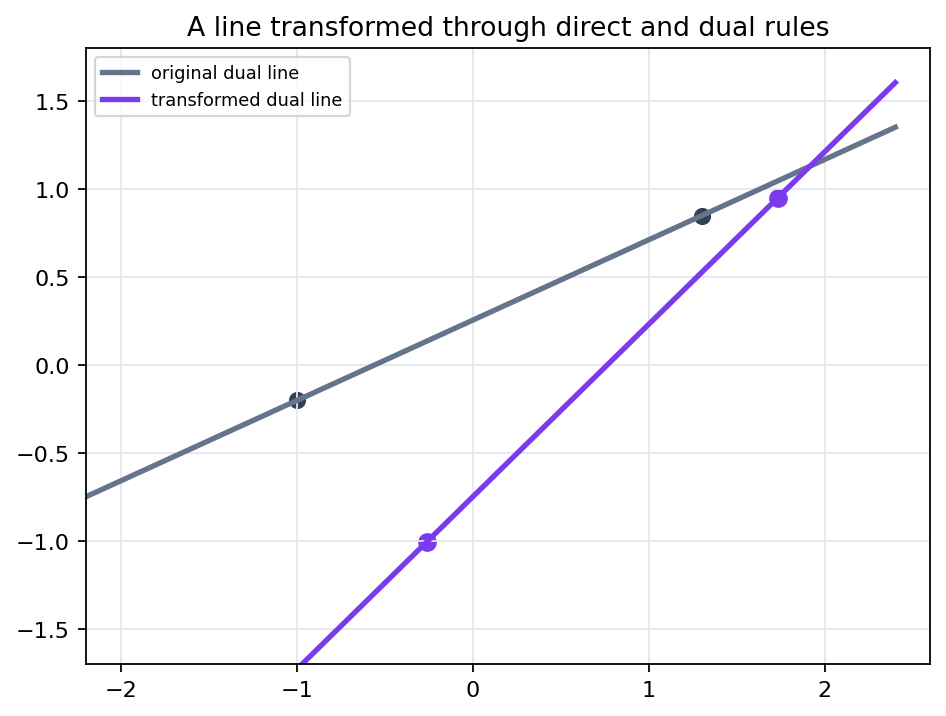

{'direct_blade_outermorphism_matches_recomputed': True,
 'dual_line_incidence_residuals': [0.0, -0.0],
 'matrix_determinant': 0.9774999999999999}

In [5]:
M = h.translation2(0.7, -0.35) @ h.rotation2(0.45) @ h.scale2(1.15, 0.85)
P0 = h.hpoint2(-1.0, -0.2)
P1 = h.hpoint2(1.3, 0.85)
line_dual = h.join_points(P0, P1)
line_blade = h.wedge_coordinates(P0, P1)
transformed_points = h.apply_homography(M, np.vstack([P0, P1]))
transformed_blade_from_points = h.wedge_coordinates(*transformed_points)
G2 = h.exterior_power_matrix(M, 2)
transformed_blade_by_outermorphism = G2 @ line_blade
transformed_dual = h.transform_line_dual(M, line_dual)
incidences_after = [h.point_line_residual(point, transformed_dual) for point in transformed_points]

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.set_title("A line transformed through direct and dual rules")
ax.set_xlim(-2.2, 2.6)
ax.set_ylim(-1.7, 1.8)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, color="#e2e8f0")
draw_line(ax, line_dual, "#64748b", "original dual line")
draw_line(ax, transformed_dual, "#7c3aed", "transformed dual line")
ax.scatter(*h.affine_location(P0), color="#334155", s=45)
ax.scatter(*h.affine_location(P1), color="#334155", s=45)
for point in transformed_points:
    ax.scatter(*h.affine_location(point), color="#7c3aed", s=55)
ax.legend(loc="upper left", fontsize=8)
transform_path = save_matplotlib(fig, "chapter-11", "direct-dual-transform", "line-transform.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(transform_path, width=740)
{
    "direct_blade_outermorphism_matches_recomputed": bool(np.allclose(transformed_blade_by_outermorphism, transformed_blade_from_points)),
    "dual_line_incidence_residuals": np.round(incidences_after, 10).tolist(),
    "matrix_determinant": float(np.linalg.det(M)),
}

## Incidence in 3-D: Lines, Planes, and Relative Orientation

The same direct/dual split appears in 3-D. A line through two finite points can be stored as a Plucker pair: a direction and a moment. The direction records the attitude of the line, while the moment records how the line misses the origin. A plane can be stored dually as a normal and offset. The incidence equation says that a homogeneous point `[x, y, z, 1]` lies on the plane `[nx, ny, nz, -delta]` when their dot product is zero.

Relative orientation is the sign information that survives inside these constructions. A line-plane meet is a finite point when the line direction has a nonzero component along the plane normal. If that denominator vanishes, the line is either parallel to the plane or already contained in it. Those cases are not mysterious; they are the same algebraic expression with a zero scalar factor.

The code below builds a 3-D line and a 3-D plane, computes their meet, and plots the result. It also checks the Plucker side condition `direction dot moment = 0`, which is the coordinate signature of a genuine line. The closest point to the origin is recovered from the Plucker pair, showing that the moment part carries metric-looking information even though the full homogeneous inner product remains suspect. This is typical of the chapter: useful quantities can be extracted, but each one needs a clear interpretation.

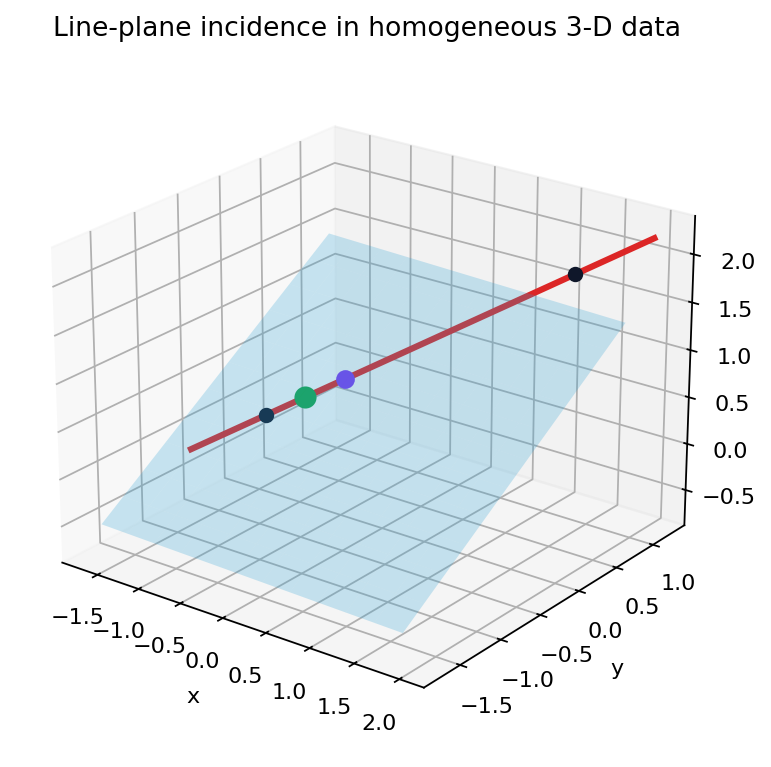

{'line_plane_kind': 'point',
 'intersection': [-0.694781, -0.234673, 0.447121],
 'plane_residual_at_intersection': -0.0,
 'plucker_side_operator': -0.0,
 'closest_point_to_origin': [-0.383101, -0.065846, 0.648414]}

In [6]:
A3 = np.array([-1.0, -0.4, 0.25])
B3 = np.array([1.4, 0.9, 1.8])
line3 = h.plucker_from_points(A3, B3)
plane3 = h.plane_from_points(
    np.array([-1.4, 0.2, 0.8]),
    np.array([1.4, 0.15, 0.55]),
    np.array([-0.6, 1.6, 1.7]),
)
kind, hit, parameter = h.line_plane_intersection(A3, B3, plane3)
closest = h.plucker_closest_to_origin(line3)

fig = plt.figure(figsize=(7.4, 5.7))
ax = fig.add_subplot(111, projection="3d")
ax.set_title("Line-plane incidence in homogeneous 3-D data")
origin, u, v = plane3.frame()
grid = np.linspace(-1.7, 1.7, 12)
U, V = np.meshgrid(grid, grid)
plane_points = origin + U[..., None] * u + V[..., None] * v
ax.plot_surface(plane_points[..., 0], plane_points[..., 1], plane_points[..., 2], alpha=0.25, color="#38bdf8", linewidth=0)
ts = np.linspace(-0.25, 1.25, 60)
line_points = A3 + ts[:, None] * (B3 - A3)
ax.plot(line_points[:, 0], line_points[:, 1], line_points[:, 2], color="#dc2626", lw=2.8)
ax.scatter(*A3, color="#0f172a", s=35)
ax.scatter(*B3, color="#0f172a", s=35)
if hit is not None:
    ax.scatter(*hit, color="#16a34a", s=80)
ax.scatter(*closest, color="#7c3aed", s=55)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=23, azim=-53)
plane_path = save_matplotlib(fig, "chapter-11", "three-dimensional-incidence", "line-plane-meet.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(plane_path, width=760)
{
    "line_plane_kind": kind,
    "intersection": None if hit is None else hit.round(6).tolist(),
    "plane_residual_at_intersection": None if hit is None else round(plane3.residual(hit), 10),
    "plucker_side_operator": round(line3.side_operator(), 10),
    "closest_point_to_origin": closest.round(6).tolist(),
}

## Parameterized Constructions

A parameterized construction is coordinate-free when the formula names geometric inputs rather than incidental coordinates. For example, a moving line can be specified as the join of a moving finite point and a moving point at infinity. The coordinates change with the parameter, but the construction reads as `point(t) join direction(t)`. That is the habit the chapter encourages for programming: write formulas that preserve geometric roles.

This style also makes degeneracies visible. If a direction vector becomes zero, the point at infinity is undefined and the construction should fail. If two points coincide, their join is not a line. If a family of lines becomes parallel, their finite intersections move toward infinity and then become explicit zero-weight points. The code can report those events with the same homogeneous representation rather than switching APIs.

The cell below creates a small family of tangent-like lines. A finite base point moves around an ellipse while the direction rotates at a different rate. Each line is built by joining the point to an improper point carrying the direction. The figure is not meant to reproduce a textbook diagram; it is a fresh visual check that the same `join` operation handles every sampled line. The saved artifact is useful because it shows the representation as a construction engine, not just a coordinate storage scheme.

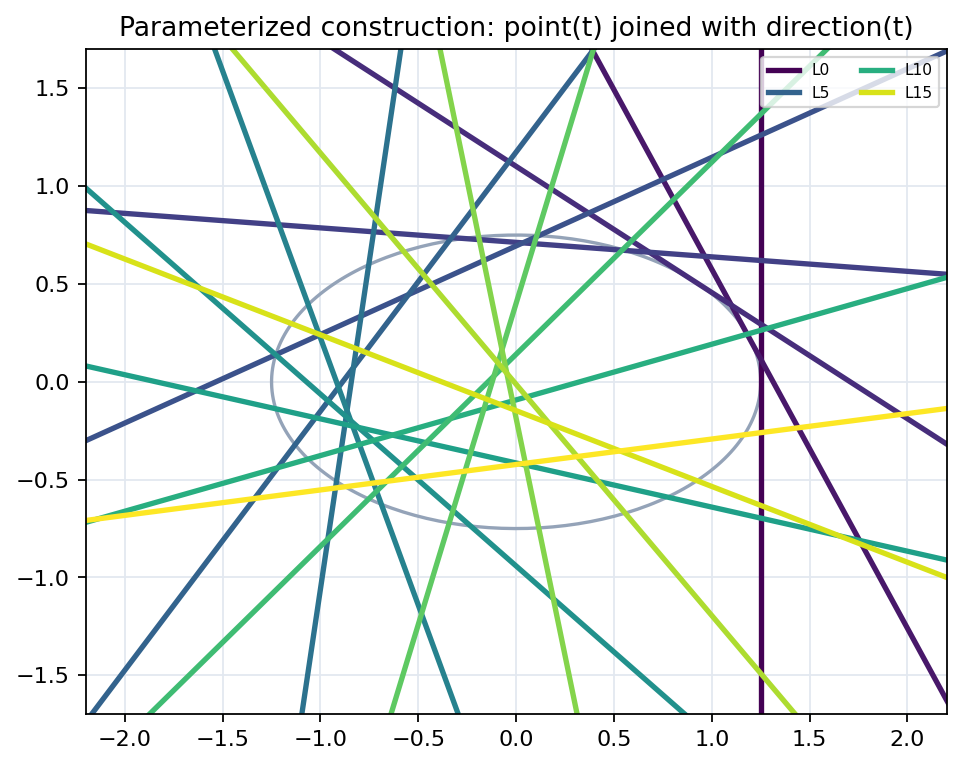

{'sample_count': 17,
 'first_line_coefficients': [-1.0, -0.0, 1.25],
 'all_lines_are_finite_dual_equations': True}

In [7]:
thetas = np.linspace(0.0, 2.0 * np.pi, 17, endpoint=False)
family = []
for theta in thetas:
    base = h.hpoint2(1.25 * np.cos(theta), 0.75 * np.sin(theta))
    direction = np.array([-np.sin(1.35 * theta), np.cos(1.35 * theta)])
    family.append(h.line_through_point_direction(base, direction))

fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.set_title("Parameterized construction: point(t) joined with direction(t)")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.7, 1.7)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, color="#e2e8f0")
ellipse = np.column_stack([1.25 * np.cos(np.linspace(0, 2*np.pi, 240)), 0.75 * np.sin(np.linspace(0, 2*np.pi, 240))])
ax.plot(ellipse[:, 0], ellipse[:, 1], color="#94a3b8", lw=1.5)
for i, line in enumerate(family):
    draw_line(ax, line, plt.cm.viridis(i / max(1, len(family) - 1)), f"L{i}" if i in (0, 5, 10, 15) else "")
ax.legend(loc="upper right", fontsize=7, ncol=2)
param_path = save_matplotlib(fig, "chapter-11", "parameterized-constructions", "line-family.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(param_path, width=760)
{
    "sample_count": len(family),
    "first_line_coefficients": family[0].round(6).tolist(),
    "all_lines_are_finite_dual_equations": bool(all(np.linalg.norm(line[:2]) > 1e-9 for line in family)),
}

## Transformations: Affine and Projective

Translations, rotations, scales, shears, and general affine maps become ordinary linear maps on homogeneous point representatives. The last coordinate remains fixed for affine maps, so finite points stay finite and the line at infinity stays the line at infinity. That is why affine maps preserve parallelism. A projective map is more general: the last row can depend on the finite coordinates, so a finite point can move toward infinity and an infinite point can become finite. These maps preserve incidence and cross ratios, but not distances or parallelism.

For direct blades, transformation is handled by outermorphism. For dual flats, transformation is handled by inverse adjoint. The notebook has already checked this for a line. The same idea scales to planes and higher flats: transform the spanning factors for direct representations, or transform the annihilating equations for dual representations. This is one of the practical reasons geometric algebra language is helpful. It prevents us from memorizing one-off formulas for every object type.

The following cell contrasts an affine map with a projective tilt. The affine map keeps the two sampled parallel lines parallel, so their meet remains an infinite point. The projective map preserves incidence but changes the line at infinity; after the projective tilt, the images of formerly parallel lines can meet at a finite point. This is a compact computational preview of why projective geometry is natural for cameras.

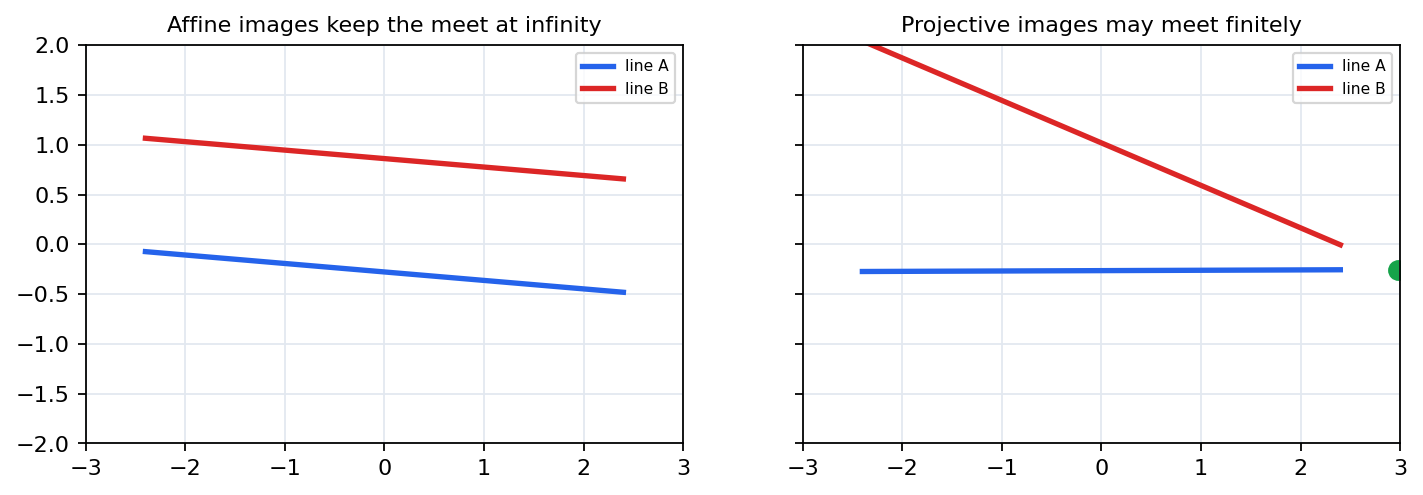

{'before_is_infinite': True,
 'after_affine_is_infinite': True,
 'after_projective_is_infinite': False,
 'projective_meet_location': [2.982315, -0.253662]}

In [8]:
base_line = h.join_points(h.hpoint2(-1.5, -0.35), h.hpoint2(1.5, 0.15))
parallel_line = h.parallel_line_through(h.hpoint2(-1.2, 0.85), base_line)
parallel_meet_before = h.meet_lines(base_line, parallel_line)
A_affine = h.translation2(0.25, -0.2) @ h.rotation2(-0.25)
H_projective = h.projective_tilt2(0.32, -0.18) @ A_affine
base_affine = h.transform_line_dual(A_affine, base_line)
parallel_affine = h.transform_line_dual(A_affine, parallel_line)
base_projective = h.transform_line_dual(H_projective, base_line)
parallel_projective = h.transform_line_dual(H_projective, parallel_line)
meet_affine = h.meet_lines(base_affine, parallel_affine)
meet_projective = h.meet_lines(base_projective, parallel_projective)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4), sharex=True, sharey=True)
for ax, title, line_a, line_b, meet in [
    (axes[0], "Affine images keep the meet at infinity", base_affine, parallel_affine, meet_affine),
    (axes[1], "Projective images may meet finitely", base_projective, parallel_projective, meet_projective),
]:
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 2)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="#e2e8f0")
    draw_line(ax, line_a, "#2563eb", "line A")
    draw_line(ax, line_b, "#dc2626", "line B")
    if not h.is_infinite(meet):
        ax.scatter(*h.affine_location(meet), color="#16a34a", s=70)
    ax.legend(loc="upper right", fontsize=7)
projective_path = save_matplotlib(fig, "chapter-11", "affine-projective", "parallel-lines-under-maps.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(projective_path, width=980)
{
    "before_is_infinite": h.is_infinite(parallel_meet_before),
    "after_affine_is_infinite": h.is_infinite(meet_affine),
    "after_projective_is_infinite": h.is_infinite(meet_projective),
    "projective_meet_location": None if h.is_infinite(meet_projective) else h.affine_location(meet_projective).round(6).tolist(),
}

## Metric Products and What They Do Not Mean

The homogeneous model is tempting because it looks like we have a full vector space with a metric. The chapter warns that this temptation should be resisted. The extra coordinate is an artificial device. If we define a naive inner product in the representation space, the result can depend on choices that have no Euclidean meaning. In particular, translating two finite point representatives changes the raw dot product even though their Euclidean distance is unchanged.

That does not mean no metric computation is possible. It means metric computations must be interpreted through the base space, through ratios that cancel unwanted factors, or through specific constructions whose meaning has been checked. Distances between finite points can be recovered after dehomogenization. Orientation signs can be extracted from determinants. Cross ratios survive projective transformations. Orthogonal projection, however, is not naturally supplied by the homogeneous inner product alone.

The cell below makes the defect concrete. It compares Euclidean distance with a naive homogeneous inner product before and after a translation. The distance is invariant under translation; the naive representation-space product is not. This small numerical test is the notebook's reminder that Chapter 11 is a projective and affine workhorse, not the final metric model of Euclidean geometry.

In [9]:
P_metric = h.hpoint2(-0.7, 1.2)
Q_metric = h.hpoint2(1.8, -0.4)
T_metric = h.translation2(4.0, -2.5)
P_trans = h.apply_homography(T_metric, P_metric)
Q_trans = h.apply_homography(T_metric, Q_metric)
metric_summary = {
    "distance_before": h.euclidean_distance(P_metric, Q_metric),
    "distance_after_translation": h.euclidean_distance(P_trans, Q_trans),
    "homogeneous_inner_before_e0_square_1": h.homogeneous_inner_points(P_metric, Q_metric, e0_square=1.0),
    "homogeneous_inner_after_e0_square_1": h.homogeneous_inner_points(P_trans, Q_trans, e0_square=1.0),
    "homogeneous_inner_before_e0_square_minus_1": h.homogeneous_inner_points(P_metric, Q_metric, e0_square=-1.0),
    "homogeneous_inner_after_e0_square_minus_1": h.homogeneous_inner_points(P_trans, Q_trans, e0_square=-1.0),
}
metric_path = save_json(metric_summary, "chapter-11", "metric-products", "metric-warning.json", root=ARTIFACT_ROOT)
metric_summary

{'distance_before': 2.968164415931166,
 'distance_after_translation': 2.9681644159311658,
 'homogeneous_inner_before_e0_square_1': -0.74,
 'homogeneous_inner_after_e0_square_1': 23.909999999999997,
 'homogeneous_inner_before_e0_square_minus_1': -2.74,
 'homogeneous_inner_after_e0_square_minus_1': 21.909999999999997}

## Cross Ratios

A distance ratio along a line can survive more transformations than a raw distance, and the cross ratio goes further: it is invariant under projective transformations. Four collinear points `A, B, C, D` define a number once we express `C` and `D` in the projective basis supplied by `A` and `B`. In affine coordinates it looks like a ratio of ratios. In homogeneous coordinates it can be computed without choosing a preferred unit length on the line.

This is exactly the sort of quantity the homogeneous model handles well. Projective transformations can bend the apparent spacing of points, send finite points toward infinity, or move the vanishing point of a family of lines, but they preserve incidence and cross ratio. That is why cross ratios show up naturally in camera geometry, image rectification, and reconstruction problems. They are measurements that do not depend on a Euclidean ruler being available in the image.

The following code uses four points on one line, applies a non-affine homography, and recomputes the cross ratio. The plotted points visibly change their spacing, but the computed invariant remains the same to numerical precision. This is the chapter's positive metric-adjacent story: not every useful measurement is Euclidean distance.

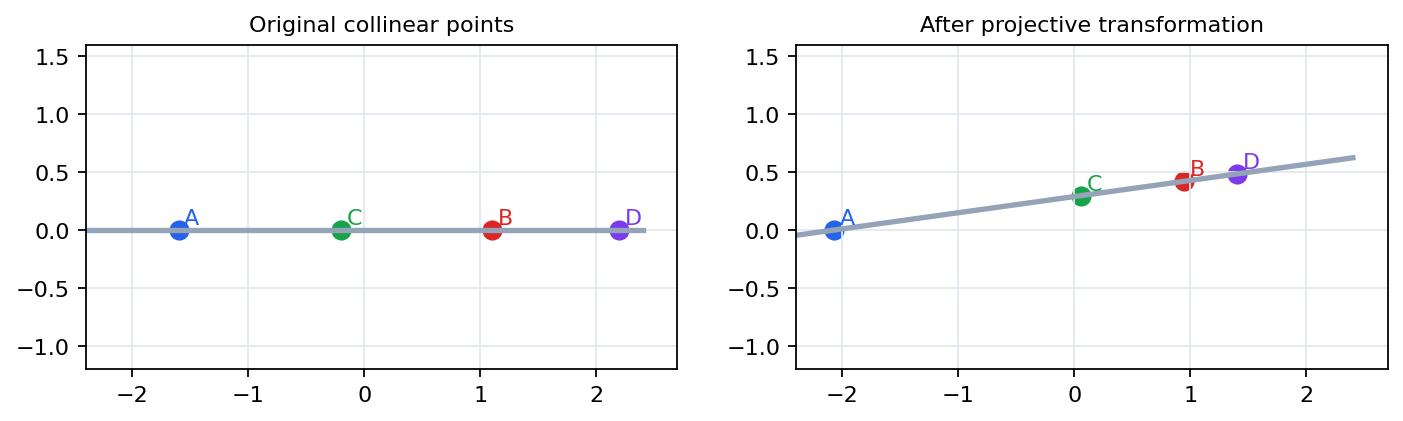

{'cross_ratio_before': -0.31174089068825916,
 'cross_ratio_after_projective_map': -0.31174089068825955,
 'absolute_error': 3.885780586188048e-16}

In [10]:
A_cr = h.hpoint2(-1.6, 0.0)
B_cr = h.hpoint2(1.1, 0.0)
C_cr = h.hpoint2(-0.2, 0.0)
D_cr = h.hpoint2(2.2, 0.0)
cr_before = h.cross_ratio_collinear(A_cr, B_cr, C_cr, D_cr)
H_cr = h.projective_tilt2(0.28, 0.05) @ h.translation2(0.25, 0.35) @ h.rotation2(0.22)
A2, B2, C2, D2 = h.apply_homography(H_cr, np.vstack([A_cr, B_cr, C_cr, D_cr]))
cr_after = h.cross_ratio_collinear(A2, B2, C2, D2)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, title, pts in [
    (axes[0], "Original collinear points", [A_cr, B_cr, C_cr, D_cr]),
    (axes[1], "After projective transformation", [A2, B2, C2, D2]),
]:
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-2.4, 2.7)
    ax.set_ylim(-1.2, 1.6)
    ax.grid(True, color="#e2e8f0")
    line = h.join_points(pts[0], pts[1])
    draw_line(ax, line, "#94a3b8", "carrier")
    for label, point, color in zip("ABCD", pts, ["#2563eb", "#dc2626", "#16a34a", "#7c3aed"]):
        xy = h.affine_location(point)
        ax.scatter(*xy, color=color, s=65)
        ax.text(xy[0] + 0.05, xy[1] + 0.05, label, color=color)
cr_path = save_matplotlib(fig, "chapter-11", "cross-ratio", "cross-ratio-invariance.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(cr_path, width=960)
{
    "cross_ratio_before": cr_before,
    "cross_ratio_after_projective_map": cr_after,
    "absolute_error": abs(cr_before - cr_after),
}

## Conics as Homogeneous Quadratic Equations

Conics are not blades in this model, but homogeneous coordinates still describe them elegantly as quadratic equations. A point conic in the projective plane can be written as `X.T @ C @ X = 0`, where `C` is a symmetric matrix and `X` is a homogeneous point. Five generic points determine a conic up to scale. Under a homography, the conic transforms by the inverse pullback so that transformed points still satisfy the transformed equation.

This section is included because the chapter's projective transformations naturally lead to conics, and because conics expose a useful boundary of the blade language. Lines, planes, and flats are represented directly as blades. Conics are represented by quadratic forms. Geometric algebra still clarifies incidence and transformation behavior, but the object is not simply a single blade in the homogeneous model. Later models and other algebras can give richer representations, but in ordinary projective coordinates the symmetric matrix is the practical form.

The cell below fits a conic through five points sampled from an ellipse, then applies a projective transformation and plots both the original and transformed conics. The residual checks verify that the five points lie on their respective conics to numerical precision. This gives the notebook a compact bridge from homogeneous flats to the camera-oriented projective material that follows in the next chapter.

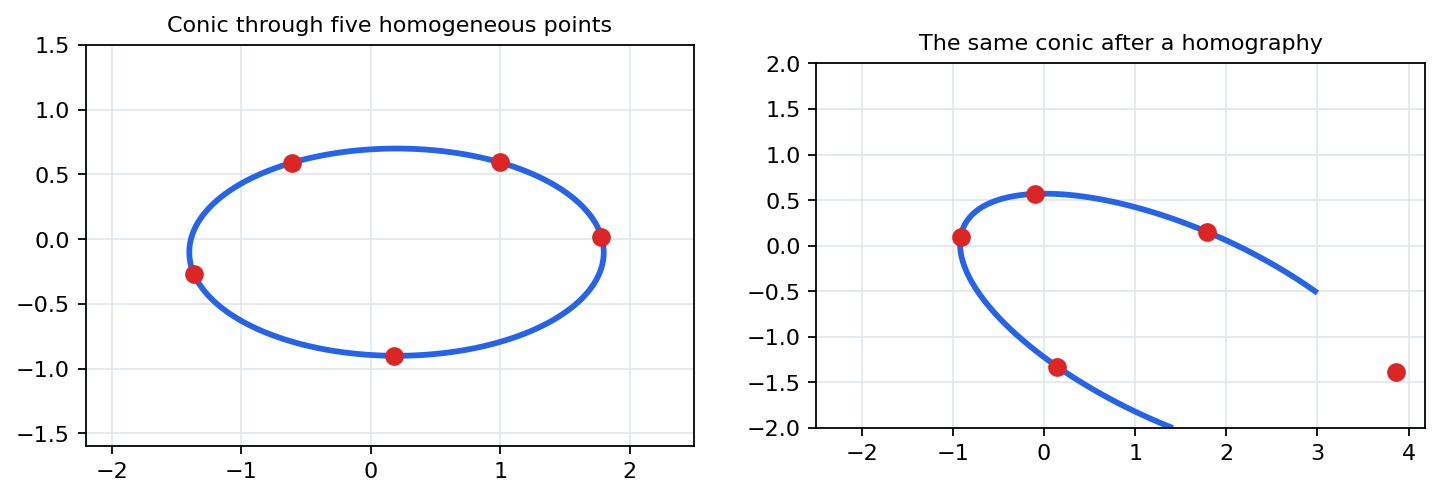

{'original_residual_max_abs': 7.771561172376096e-16,
 'transformed_residual_max_abs': 8.881784197001252e-16,
 'conic_determinant': 0.08959886839752482}

In [11]:
angles = np.array([0.15, 1.05, 2.1, 3.35, 4.7])
ellipse_points = [h.hpoint2(1.6 * np.cos(t) + 0.2, 0.8 * np.sin(t) - 0.1) for t in angles]
conic = h.conic_from_five_points(ellipse_points)
H_conic = h.projective_tilt2(-0.18, 0.22) @ h.translation2(0.25, -0.1) @ h.rotation2(-0.35)
transformed_conic = h.transform_conic(H_conic, conic)
transformed_points = h.apply_homography(H_conic, np.vstack(ellipse_points))
residuals_original = h.evaluate_conic(conic, np.vstack(ellipse_points))
residuals_transformed = h.evaluate_conic(transformed_conic, transformed_points)

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8))
for ax, title, C, pts, bounds in [
    (axes[0], "Conic through five homogeneous points", conic, np.vstack(ellipse_points), (-2.2, 2.5, -1.6, 1.5)),
    (axes[1], "The same conic after a homography", transformed_conic, transformed_points, (-2.5, 3.0, -2.0, 2.0)),
]:
    xx, yy, zz = h.conic_grid(C, bounds=bounds, resolution=360)
    ax.contour(xx, yy, zz, levels=[0.0], colors=["#2563eb"], linewidths=2.6)
    finite_pts = np.array([h.affine_location(p) for p in pts])
    ax.scatter(finite_pts[:, 0], finite_pts[:, 1], color="#dc2626", s=55, zorder=3)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="#e2e8f0")
conic_path = save_matplotlib(fig, "chapter-11", "conics", "conic-homography.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(conic_path, width=980)
{
    "original_residual_max_abs": float(np.max(np.abs(residuals_original))),
    "transformed_residual_max_abs": float(np.max(np.abs(residuals_transformed))),
    "conic_determinant": float(np.linalg.det(conic)),
}

## Perspective Projection

Perspective projection is a final demonstration of the homogeneous model as a programming language for incidence. A camera center and an image plane define the projection. For each 3-D vertex, construct the line through the camera and the vertex, then meet that line with the image plane. The result is an image-plane point. This is the same join-and-meet idea used earlier for lines in the plane, now applied to 3-D rays and a plane.

A conventional graphics pipeline would package this as a projection matrix, and that is the fastest form for rendering. The blade-oriented construction is still valuable because it exposes the geometry: projection is not magic matrix multiplication, but line-plane incidence repeated for many vertices. Orthographic projection can be described separately by dropping points along a fixed direction or along the plane normal, which also clarifies why the homogeneous model's naive metric product is not enough to define orthogonal projection by itself.

The next cell projects the vertices of a cube from a camera center onto an oblique image plane. The 3-D figure shows the cube, camera, selected rays, image plane, and projected edge network. The 2-D inset shows the coordinates recovered in the image-plane frame. Both are saved as artifacts. This example intentionally uses the generic line-plane construction rather than a prebuilt projection matrix so the incidence workflow remains visible.

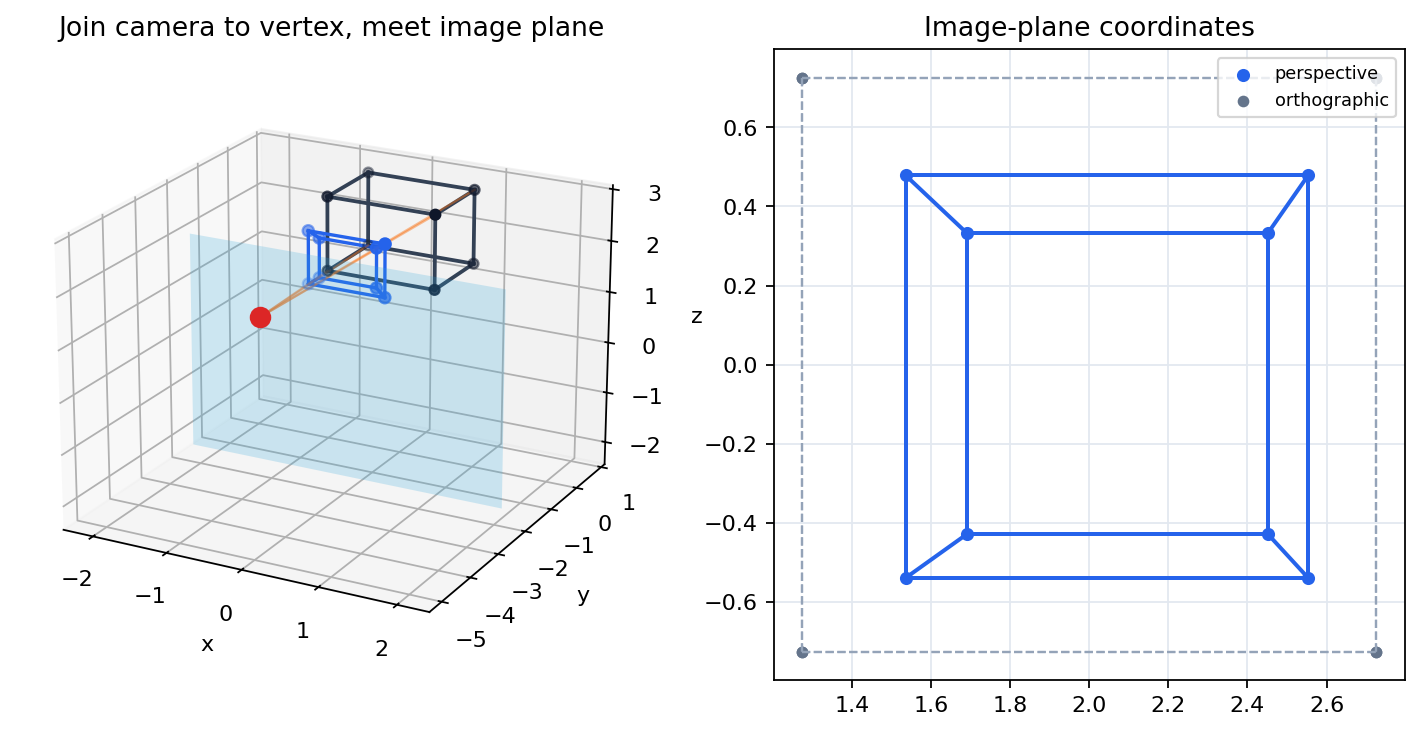

{'max_plane_residual_perspective': 0.0,
 'projected_vertex_0_plane_coordinates': [1.535965, 0.478947],
 'orthographic_vertex_0_plane_coordinates': [1.275, 0.725]}

In [12]:
cube = h.cube_vertices(size=1.45, center=(0.0, 0.0, 2.0))
edges = h.cube_edges()
camera = np.array([0.1, -5.0, 2.15])
image_plane = h.plane_from_points(
    np.array([-1.8, -2.0, 0.65]),
    np.array([1.9, -2.0, 0.8]),
    np.array([-1.65, -2.0, 3.4]),
)
projected3, projected2 = h.perspective_project_points(cube, camera, image_plane)
orthographic3, orthographic2 = h.orthographic_project_points(cube, image_plane)

fig = plt.figure(figsize=(11.2, 5.4))
ax3 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122)
ax3.set_title("Join camera to vertex, meet image plane")
origin, u, v = image_plane.frame()
plane_grid = np.linspace(-2.1, 2.1, 2)
U, V = np.meshgrid(plane_grid, plane_grid)
plane_pts = origin + U[..., None] * u + V[..., None] * v
ax3.plot_surface(plane_pts[..., 0], plane_pts[..., 1], plane_pts[..., 2], alpha=0.22, color="#38bdf8", linewidth=0)
for i, j in edges:
    ax3.plot(*zip(cube[i], cube[j]), color="#334155", lw=1.7)
    ax3.plot(*zip(projected3[i], projected3[j]), color="#2563eb", lw=1.5)
for idx in [0, 2, 5, 7]:
    ax3.plot(*zip(camera, cube[idx]), color="#f97316", alpha=0.45, lw=1.0)
ax3.scatter(cube[:, 0], cube[:, 1], cube[:, 2], color="#0f172a", s=20)
ax3.scatter(projected3[:, 0], projected3[:, 1], projected3[:, 2], color="#2563eb", s=26)
ax3.scatter(*camera, color="#dc2626", s=75)
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.view_init(elev=21, azim=-62)
ax2.set_title("Image-plane coordinates")
for i, j in edges:
    ax2.plot([projected2[i, 0], projected2[j, 0]], [projected2[i, 1], projected2[j, 1]], color="#2563eb", lw=1.8)
    ax2.plot([orthographic2[i, 0], orthographic2[j, 0]], [orthographic2[i, 1], orthographic2[j, 1]], color="#94a3b8", lw=1.0, ls="--")
ax2.scatter(projected2[:, 0], projected2[:, 1], color="#2563eb", s=24, label="perspective")
ax2.scatter(orthographic2[:, 0], orthographic2[:, 1], color="#64748b", s=18, label="orthographic")
ax2.set_aspect("equal", adjustable="box")
ax2.grid(True, color="#e2e8f0")
ax2.legend(loc="upper right", fontsize=8)
projection_path = save_matplotlib(fig, "chapter-11", "perspective-projection", "cube-projection.png", root=ARTIFACT_ROOT)
plt.close(fig)

display_artifact(projection_path, width=1050)
{
    "max_plane_residual_perspective": float(np.max(np.abs([image_plane.residual(p) for p in projected3]))),
    "projected_vertex_0_plane_coordinates": projected2[0].round(6).tolist(),
    "orthographic_vertex_0_plane_coordinates": orthographic2[0].round(6).tolist(),
}

## Final Sanity Checks

The notebook's computations are small, but they cover the chapter's main invariants. A finite point must dehomogenize correctly. Parallel lines must meet at infinity. A transformed direct blade must agree with wedging transformed factors. A transformed dual line must annihilate transformed points. The naive homogeneous inner product must fail the translation-invariance test, reminding us not to treat it as a Euclidean distance product. A cross ratio must survive a projective map. A fitted conic must contain the points used to define it, and perspective-projected vertices must lie on the image plane.

Those checks do not prove a full geometric algebra implementation. They are a quality gate for this chapter notebook: they make sure the examples are not just decorative, and they connect each saved artifact to a numerical invariant. If one of these assertions fails, the failure points to a conceptual mismatch rather than a random plotting issue.

The final cell writes `sanity-checks.json` under the chapter artifact directory and raises immediately on failure. This makes the notebook suitable for automated execution with `nbconvert` or `nbclient` while still being readable as a study document.

In [13]:
checks = {
    "finite_point_normalizes": bool(np.allclose(h.normalize_hpoint(h.hpoint2(6.0, -3.0, 3.0)), h.hpoint2(2.0, -1.0, 1.0))),
    "parallel_lines_meet_at_infinity": bool(h.is_infinite(infinite_meet)),
    "direct_blade_transform_matches": bool(np.allclose(transformed_blade_by_outermorphism, transformed_blade_from_points)),
    "dual_line_incidence_after_transform": bool(np.max(np.abs(incidences_after)) < 1e-8),
    "distance_survives_translation": bool(abs(metric_summary["distance_before"] - metric_summary["distance_after_translation"]) < 1e-9),
    "naive_inner_changes_under_translation": bool(abs(metric_summary["homogeneous_inner_before_e0_square_1"] - metric_summary["homogeneous_inner_after_e0_square_1"]) > 1e-6),
    "cross_ratio_projective_invariant": bool(abs(cr_before - cr_after) < 1e-9),
    "conic_contains_seed_points": bool(np.max(np.abs(residuals_original)) < 1e-9),
    "transformed_conic_contains_transformed_points": bool(np.max(np.abs(residuals_transformed)) < 1e-9),
    "perspective_points_lie_on_image_plane": bool(np.max(np.abs([image_plane.residual(p) for p in projected3])) < 1e-9),
}
checks_path = save_json(checks, "chapter-11", "sanity-checks", "sanity-checks.json", root=ARTIFACT_ROOT)
if not all(checks.values()):
    raise AssertionError({key: value for key, value in checks.items() if not value})
checks

{'finite_point_normalizes': True,
 'parallel_lines_meet_at_infinity': True,
 'direct_blade_transform_matches': True,
 'dual_line_incidence_after_transform': True,
 'distance_survives_translation': True,
 'naive_inner_changes_under_translation': True,
 'cross_ratio_projective_invariant': True,
 'conic_contains_seed_points': True,
 'transformed_conic_contains_transformed_points': True,
 'perspective_points_lie_on_image_plane': True}

## Takeaways

- `Chapter 11: The Homogeneous Model` is treated as an executable geometric algebra lesson: definitions are paired with concrete representations, artifacts, and checks.
- The chapter's computations make the model choices visible, so algebraic operations can be inspected instead of accepted as black-box notation.
- The saved artifacts and sanity checks are the audit trail for this standalone notebook; they support the text without reproducing textbook prose or figures.